
# Baseline PCA Response Model for CAR-T T-cell Data

This notebook:

- uses **baseline only** (`TIMEPOINT == 0`)
- filters to **`PRODUCT == 1`**
- computes **baseline-only PCA** from the full-gene matrix in `raw_adata`
- averages PCA coordinates per patient
- trains a **logistic regression** model to predict `BEST_RESPONSE_CONSENSUS`
- plots the ROC curve

**Assumptions**
- `raw_adata` is already loaded in memory
- `raw_adata.X` contains log-normalized expression
- `BEST_RESPONSE_CONSENSUS` is a binary patient-level label


In [1]:
import anndata as ad
adata = ad.read_h5ad("/home/haitham/mnt/DATA/cart/meta/integration/06_seurat_harmony_t_all_new.h5ad")

/home/haitham/scFM_eval/.pixi/envs/geneformer/lib/python3.11/site-packages/anndata/_io/h5ad.py:267: FutureWarning: Moving element from .uns['neighbors']['distances'] to .obsp['distances'].

This is where adjacency matrices should go now.
  return AnnData(**{


In [4]:
raw_adata = adata.raw.to_adata()

In [5]:

import scanpy as sc
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, average_precision_score, roc_curve


## 1) Subset to baseline and `PRODUCT == 1`

In [6]:

ad0 = raw_adata[raw_adata.obs["TIMEPOINT"] == 0].copy()
ad0 = ad0[pd.to_numeric(ad0.obs["PRODUCT"], errors="coerce") == 1].copy()

print(ad0)
print("Patients:", ad0.obs["PATIENT_ID"].nunique())
print("Samples:", ad0.obs["SAMPLE_ID"].nunique())

resp_preview = ad0.obs[["PATIENT_ID", "BEST_RESPONSE_CONSENSUS"]].drop_duplicates()
print("\nResponse labels:")
print(resp_preview["BEST_RESPONSE_CONSENSUS"].value_counts(dropna=False))


AnnData object with n_obs × n_vars = 30559 × 36602
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'nCount_ADT', 'nFeature_ADT', 'STUDY', 'WELL', 'WELL_SPLIT', 'lane', 'CD4CD8_BY_EXPRS', 'CD3_BY_EXPRS', 'CAR_BY_EXPRS', 'Perc_of_mito_genes', 'Perc_of_ribosomal_genes', 'log10GenesPerUMI', 'S.Score', 'G2M.Score', 'CellCycle', 'CellCycle_Phase', 'CellCycle_SCORE_UCell', 'T_LIN', 'celltype', 'celltype_short_2', 'celltype_short_3', 'VDJ_T_AVAIL', 'VDJ_B_AVAIL', 'PATIENT_ID', 'SAMPLE_ID', 'TIME_APHERESIS_CAR', 'TIME_CAR_DAY_30', 'TIME_CAR_DAY_100', 'SEX', 'AGE_AT_DIAGNOSIS', 'AGE_AT_CAR', 'TIME_DIAGNOSE_CAR', 'PRODUCT', 'STAGING_SALMON_DURIE', 'R_ISS', 'PROGRESSION_BEFORE_CART', 'STATUS_BEFORE_CAR', 'THERAPY_PRIOR_APHERESIS_GROUP', 'RESPONSE_1_M', 'RESPONSE_3_M', 'RESPONSE_6_M', 'RESPONSE_12_M', 'BEST_RESPONSE', 'BEST_RESPONSE_CONSENSUS', 'PROGRESSION', 'PFS', 'TOCI', 'CRS_GRADE', 'CRS', 'CRS_GROUP', 'ICANS', 'CRP_MAX', 'TIMEPOINT'
    var: '_index'
    uns: 'neighbors'
    obsm: 'X_harm

## 2) Compute PCA on baseline cells only

In [7]:

X = ad0.X
if hasattr(X, "toarray"):  # sparse
    frac_expr = np.asarray((X > 0).sum(axis=0)).ravel() / ad0.n_obs
else:
    frac_expr = (X > 0).mean(axis=0)

ad0 = ad0[:, frac_expr >= 0.01].copy()
print("Genes after filtering:", ad0.n_vars)

sc.pp.highly_variable_genes(ad0, n_top_genes=2000, flavor="seurat")
ad0 = ad0[:, ad0.var["highly_variable"]].copy()
print("Genes after HVG:", ad0.n_vars)

# The matrix appears already log-normalized, so do not normalize/log1p again.
sc.pp.scale(ad0, max_value=10)
sc.tl.pca(ad0, n_comps=30)

print("PCA shape:", ad0.obsm["X_pca"].shape)


Genes after filtering: 11374
Genes after HVG: 2000


/home/haitham/scFM_eval/.pixi/envs/geneformer/lib/python3.11/functools.py:909: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)


PCA shape: (30559, 30)


## 3) Average PCA coordinates per patient

In [8]:

patient_ids = ad0.obs["PATIENT_ID"].astype(str).values
unique_patients = pd.Index(sorted(pd.unique(patient_ids)))

P = ad0.obsm["X_pca"]

patient_pca = []
for pid in unique_patients:
    idx = np.where(patient_ids == pid)[0]
    patient_pca.append(P[idx].mean(axis=0))

X_patient = pd.DataFrame(
    np.vstack(patient_pca),
    index=unique_patients,
    columns=[f"pc_{i+1}" for i in range(P.shape[1])]
)

print(X_patient.shape)
X_patient.head()


(31, 30)


,pc_1,pc_2,pc_3,pc_4,pc_5,pc_6,pc_7,pc_8,pc_9,pc_10,...,pc_21,pc_22,pc_23,pc_24,pc_25,pc_26,pc_27,pc_28,pc_29,pc_30
0,0.298593,-6.211524,-1.673242,1.297971,-0.006796,1.610259,-2.031994,0.194115,0.454156,-1.226155,...,-0.388396,-1.351446,-0.591451,-0.172299,0.139369,1.028344,0.036777,-0.836751,-0.393699,0.428034
1,0.159632,-0.286506,3.699309,5.052938,-1.005252,-0.540155,-1.018958,-0.535245,0.244285,0.219970,...,1.108895,0.439678,-0.189353,0.662894,1.435884,-0.773025,-0.361213,0.508977,-0.447065,-0.920934
10,-4.828206,0.772846,0.190856,0.602283,-0.020003,-0.448753,-1.506547,-0.455734,-1.077496,0.134967,...,-0.330497,-0.402981,-0.135185,-0.014574,-0.519354,0.162242,-0.106110,-0.658108,-0.276112,-0.328054
11,-0.622820,-6.866308,-5.551667,0.275446,0.478650,0.425984,2.334480,-1.026845,1.624214,2.136082,...,0.350348,0.983685,-0.570347,-0.365100,-0.601228,-0.655063,-0.550892,0.530398,-0.114483,-1.203132
12,1.274110,-3.040570,-1.180807,0.917322,1.440690,0.331610,-0.959143,0.657786,-0.487024,-0.971207,...,-0.127243,-0.786763,-0.844045,1.115305,-0.209581,0.604377,-0.268683,0.045360,1.305145,0.383088


## 4) Fit response model

In [9]:

resp_df = (
    ad0.obs[["PATIENT_ID", "BEST_RESPONSE_CONSENSUS"]]
    .drop_duplicates()
    .copy()
)
resp_df["PATIENT_ID"] = resp_df["PATIENT_ID"].astype(str)
resp_df["y_response"] = pd.to_numeric(resp_df["BEST_RESPONSE_CONSENSUS"], errors="coerce")
resp_df = resp_df[["PATIENT_ID", "y_response"]].dropna().drop_duplicates("PATIENT_ID")

df_resp = X_patient.join(resp_df.set_index("PATIENT_ID"), how="inner")

print("Patients with labels:", len(df_resp))
print(df_resp["y_response"].value_counts())

X = df_resp.drop(columns="y_response")
y = df_resp["y_response"].astype(int)

clf = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        penalty="l2",
        C=1.0,
        max_iter=5000,
        class_weight="balanced"
    ))
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
pred_prob = cross_val_predict(clf, X, y, cv=cv, method="predict_proba")[:, 1]

auc = roc_auc_score(y, pred_prob)
auprc = average_precision_score(y, pred_prob)

print("AUROC:", round(auc, 3))
print("AUPRC:", round(auprc, 3))


Patients with labels: 31
y_response
1    19
0    12
Name: count, dtype: int64
AUROC: 0.307
AUPRC: 0.571


/home/haitham/scFM_eval/.pixi/envs/geneformer/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/home/haitham/scFM_eval/.pixi/envs/geneformer/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/home/haitham/scFM_eval/.pixi/envs/geneformer/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' wa

## 5) Plot ROC

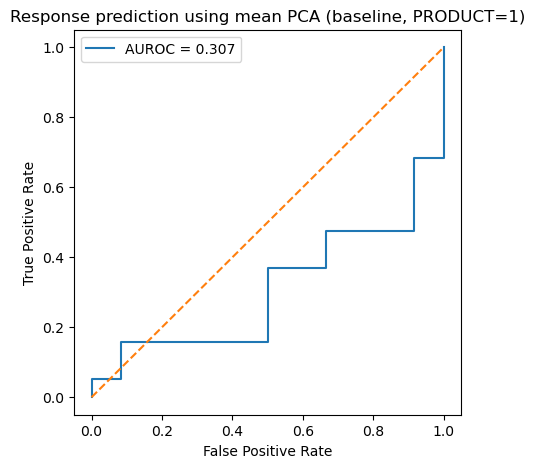

In [10]:

fpr, tpr, _ = roc_curve(y, pred_prob)

plt.figure(figsize=(5, 5))
plt.plot(fpr, tpr, label=f"AUROC = {auc:.3f}")
plt.plot([0, 1], [0, 1], "--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Response prediction using mean PCA (baseline, PRODUCT=1)")
plt.legend()
plt.show()


In [11]:
from sklearn.model_selection import LeaveOneOut, cross_val_predict

resp_df = (
    ad0.obs[["PATIENT_ID", "BEST_RESPONSE_CONSENSUS"]]
    .drop_duplicates()
    .copy()
)
resp_df["PATIENT_ID"] = resp_df["PATIENT_ID"].astype(str)
resp_df["y_response"] = pd.to_numeric(resp_df["BEST_RESPONSE_CONSENSUS"], errors="coerce")
resp_df = resp_df[["PATIENT_ID", "y_response"]].dropna().drop_duplicates("PATIENT_ID")

df_resp = X_patient.join(resp_df.set_index("PATIENT_ID"), how="inner")

print("Patients with labels:", len(df_resp))
print(df_resp["y_response"].value_counts())

X = df_resp.drop(columns="y_response")
y = df_resp["y_response"].astype(int)

clf = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        penalty="l2",
        C=1.0,
        max_iter=5000,
        class_weight="balanced"
    ))
])

loo = LeaveOneOut()

pred_prob = cross_val_predict(
    clf,
    X,
    y,
    cv=loo,
    method="predict_proba"
)[:, 1]

auc = roc_auc_score(y, pred_prob)
auprc = average_precision_score(y, pred_prob)

print("LOOCV AUROC:", round(auc, 3))
print("LOOCV AUPRC:", round(auprc, 3))

Patients with labels: 31
y_response
1    19
0    12
Name: count, dtype: int64


/home/haitham/scFM_eval/.pixi/envs/geneformer/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/home/haitham/scFM_eval/.pixi/envs/geneformer/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/home/haitham/scFM_eval/.pixi/envs/geneformer/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' wa

LOOCV AUROC: 0.382
LOOCV AUPRC: 0.595


/home/haitham/scFM_eval/.pixi/envs/geneformer/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/home/haitham/scFM_eval/.pixi/envs/geneformer/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/home/haitham/scFM_eval/.pixi/envs/geneformer/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' wa

## Optional: add T-cell subtype proportions

In [ ]:

celltype_col = "celltype_short_3"

comp = (
    ad0.obs[["PATIENT_ID", celltype_col]]
    .assign(n=1)
    .pivot_table(index="PATIENT_ID", columns=celltype_col, values="n", aggfunc="sum", fill_value=0)
)
comp = comp.div(comp.sum(axis=1), axis=0)
comp.columns = [f"prop_{c}" for c in comp.columns]

X_patient2 = X_patient.join(comp, how="left")
print(X_patient2.shape)
X_patient2.head()


## Notes


- If `sc.pp.scale()` uses too much memory, a lighter alternative is `TruncatedSVD`.
- This is a **patient-level** model. Do not train on cells as independent examples for patient-level labels.
- A good next comparison is:
  1. mean paper `X_harmony`
  2. baseline-only mean PCA
  3. baseline-only mean PCA + subtype proportions
